# Model Predictions and Visualization

This notebook loads trained convCNP models and visualizes predictions on holdout time periods.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout time period for that fold
3. Select one deterministic day from the holdout period
4. Generate predictions for all spatial points using configurable context input:
   - **ERA5_GRID**: Full or sparse ERA5-Local gridded data
   - **METEOSWISS**: Sparse MeteoSwiss observations placed on the ERA5 grid
   - Sparsity is controlled via `SPARSITY_TYPE` (PERCENT or ABSOLUTE) and the corresponding setting
5. Plot side-by-side heatmaps: ERA5 Input | Ground Truth | Predictions | Bias

After processing all folds, the holdout predictions are combined (since holdout periods are non-overlapping) to produce a single unified evaluation with error maps, uncertainty calibration, CRPS, and skill scores.

In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
MODEL_NAME = 'final-2014-30e-5f-6in-mean'

from typing import Literal

_ERA5_GRID = 'ERA5_GRID'
_METEOSWISS = 'METEOSWISS'
_PERCENT = 'PERCENT'         # used to specify a percentage of points to pass in as input
_ABSOLUTE = 'ABSOLUTE'       # used to pass in a number of sampled points as input

INPUT_DATA: Literal['ERA5_GRID', 'METEOSWISS'] = _ERA5_GRID
SPARSITY_TYPE: Literal['PERCENT', 'ABSOLUTE'] = _PERCENT
SPARSITY_PERCENT: float | None = 1.0  # 0-1, fraction of data points to keep
SPARSITY_POINTS: int | None = 250  # integer number of data points to keep


def use_era5_input():
    return INPUT_DATA == _ERA5_GRID

def use_meteoswiss_input():
    return INPUT_DATA == _METEOSWISS

def is_sparse_percent():
    return SPARSITY_TYPE == _PERCENT

def sparse_percent():
    if not is_sparse_percent():
        raise AttributeError('Not using sparse percentages')
    return SPARSITY_PERCENT

def is_sparse_points():
    return SPARSITY_TYPE == _ABSOLUTE

def sparse_points():
    if not is_sparse_points():
        raise AttributeError('Not using sparse points')
    return SPARSITY_POINTS


assert use_era5_input() or use_meteoswiss_input()
if is_sparse_percent():
    assert SPARSITY_PERCENT is not None and 0 < SPARSITY_PERCENT <= 1.0
if is_sparse_points():
    assert SPARSITY_POINTS is not None and SPARSITY_POINTS > 0

In [3]:
from pathlib import Path

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import torch

import datasets as ds
import inference as inf
import metrics
import model_factory
import visualization as vis
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

In [4]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [5]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models') / MODEL_NAME

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'
DEFAULT_ERA5_MEAN_TEMP_GLOB         = './datasets/ERA5_Land/temperature/*.nc'
DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB  = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'

In [6]:
# Build plot output directory and filename prefix
# Convention: {INPUT_DATA}_{SPARSITY_TYPE}_{value}_{plot_name}.png
sparsity_value = SPARSITY_PERCENT if is_sparse_percent() else SPARSITY_POINTS
PLOT_PREFIX = f"{INPUT_DATA}_{SPARSITY_TYPE}_{sparsity_value}"
PLOT_DIR = MODEL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(name: str) -> Path:
    """Return full path for a plot file: MODEL_DIR/plots/{prefix}_{name}.png"""
    return PLOT_DIR / f"{PLOT_PREFIX}_{name}.png"

print(f"Plots will be saved to: {PLOT_DIR}")
print(f"Filename prefix: {PLOT_PREFIX}")

Plots will be saved to: trained_models/final-2014-30e-5f-6in-mean/plots
Filename prefix: ERA5_GRID_PERCENT_1.0


In [7]:
import cloud_sync

REMOTE_MODEL_DIR = Path().cwd() / '..' / 'trained-models-mount' / MODEL_NAME
RUN_TYPE = 'cloud' if params.is_renku() else 'local'
cloud_sync.sync_from_cloud_if_needed(REMOTE_MODEL_DIR, MODEL_DIR, RUN_TYPE)

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../trained-models-mount/final-2014-30e-5f-6in-mean to trained_models/final-2014-30e-5f-6in-mean...
Synchronizing directory trained_models/final-2014-30e-5f-6in-mean with /home/renku/work/convNPClimate/../trained-models-mount/final-2014-30e-5f-6in-mean
Source directory: /home/renku/work/convNPClimate/../trained-models-mount/final-2014-30e-5f-6in-mean:


dirsync finished in 0.08 seconds.
2 directories parsed, 0 files copied

Dataset sync complete.


/home/renku/work/.venv/lib/python3.13/site-packages/dirsync/syncer.py:104: SyntaxWarning: invalid escape sequence '\.'
  self._exclude.append('^\.dirsync$')


True

## Load Training Configuration

In [8]:
# Load params and metadata from training
params = params.Params.load_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH

TEMPERATURE_TYPE = getattr(params, 'TEMPERATURE_TYPE', 'max')

if TEMPERATURE_TYPE == 'max':
    ERA5_TEMP_GLOB        = params.ERA5_MAX_TEMP_GLOB  or DEFAULT_ERA5_MAX_TEMP_GLOB
    ERA5_VAR_NAME         = 't2m_max'
    METEO_SWISS_TEMP_GLOB = params.METEO_SWISS_MAX_TEMP_GLOB or DEFAULT_METEO_SWISS_MAX_TEMP_GLOB
    METEO_SWISS_VAR       = 'TmaxD'
else:
    ERA5_TEMP_GLOB        = params.ERA5_MEAN_TEMP_GLOB  or DEFAULT_ERA5_MEAN_TEMP_GLOB
    ERA5_VAR_NAME         = 't2m'
    METEO_SWISS_TEMP_GLOB = params.METEO_SWISS_MEAN_TEMP_GLOB or DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB
    METEO_SWISS_VAR       = 'TabsD'


print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 temp: {ERA5_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  MeteoSwiss: {METEO_SWISS_TEMP_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")

Loaded configuration for run: final-2014-30e-5f-6in-mean
  Variable: tmax
  Data year start: 2014
  N folds: 5
  Model: 128 channels, 6 blocks
  ERA5 temp: datasets/ERA5_Land/temperature/*.nc
  ERA5 geopotential: datasets/ERA5_Land/geopotential/*.nc
  MeteoSwiss: datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc
  Topography: datasets/topo_subset.zarr


## Load Data

In [9]:
# Load ERA5 input data with geopotential
era5_data, _, era5_grid_elevation, era5_times = ds.load_era5_data(
    ERA5_TEMP_GLOB,
    var_name=ERA5_VAR_NAME,
    year_start=params.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    include_seasonal_embeddings=params.SEASONAL_FEATURES,
    include_altitude=True,
    device=device
)

print(f"ERA5 data shape: {era5_data.shape}")
print(f"Time coordinates: {len(era5_times)} dates from {era5_times[0]} to {era5_times[-1]}")

# Compute seasonal features from time coordinates if the model was trained with them
# SEASONAL_FEATURES=False should disable seasonal features everywhere.
# The model's use_seasonal_in_mlp flag (from SEASONAL_FEATURES_IN_MLP) independently
# controls whether the MLP actually uses these features.
if params.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(era5_times, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (n_times, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled (model was trained without them)")

# Load high-resolution topography (DEM and TPI)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading ERA5 data from: datasets/ERA5_Land/temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2014: 2014-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 3652, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([3652, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon r

In [10]:
# Load MeteoSwiss targets with elevation and TPI
target_x, target_y, target_topo = ds.prepare_meteoswiss_targets(
    METEO_SWISS_TEMP_GLOB,
    normalization_stats=metadata,
    data_var=METEO_SWISS_VAR,
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=params.DATA_YEAR_START,
    device=device,
)

# Convert to tensors
target_y_tensor = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"Target Y shape: {target_y_tensor.shape}")
print(f"Target topo shape: {target_topo.shape}")

# Get grid shape for reshaping predictions
grid_N, grid_E = ds.get_meteoswiss_grid_shape(METEO_SWISS_TEMP_GLOB)
print(f"MeteoSwiss grid shape: ({grid_N}, {grid_E})")

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TabsD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [11]:
# Calculate distances
dists = ds.calculate_dists_meteoswiss(metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

# Elevation tensor is already loaded as target_topo
elev = target_topo
print(f"Elevation tensor shape: {elev.shape}")

Distances shape: torch.Size([88800, 29, 61])
Elevation tensor shape: torch.Size([88800, 3])


In [12]:
# Build context_data: the input tensor for predictions.
# For full ERA5: identical to era5_data (no NaN).
# For sparse ERA5: era5_data with NaN at masked-out grid cells.
# For MeteoSwiss: MeteoSwiss observations placed on the ERA5 grid, NaN elsewhere.
# The model's predict_single_day derives the mask from NaN in channel 0.

era5_shape = (era5_data.shape[2], era5_data.shape[3])  # (lat, lon)

if use_meteoswiss_input():
    if is_sparse_points():
        sparse_indices = ds.sample_meteoswiss_points(target_y_tensor, n_points=sparse_points(), seed=params.SEED)
    else:
        sparse_indices = ds.sample_meteoswiss_points(target_y_tensor, frac=sparse_percent(), seed=params.SEED)
    sparse_lat_idx, sparse_lon_idx = ds.find_nearest_era5_indices(target_x, metadata, sparse_indices)

    # Build full context tensor: MeteoSwiss sparse observations on ERA5 grid
    context_data = era5_data.clone()
    context_data[:, 0, :, :] = float('nan')

    # For each unique ERA5 cell, average the MeteoSwiss points mapping to it
    unique_cells = set(zip(sparse_lat_idx.tolist(), sparse_lon_idx.tolist()))
    for lat_i, lon_i in unique_cells:
        cell_mask = (sparse_lat_idx == lat_i) & (sparse_lon_idx == lon_i)
        cell_points = sparse_indices[cell_mask]
        cell_values = target_y_tensor[:, cell_points]  # (n_times, n_cell_points)
        context_data[:, 0, lat_i, lon_i] = torch.nanmean(cell_values, dim=1)  # NaN if all NaN

    n_observed = (~torch.isnan(context_data[0, 0])).sum().item()
    print(f"Built MeteoSwiss sparse context: {context_data.shape}")
    print(f"  {n_observed} observed ERA5 grid cells (of {era5_shape[0] * era5_shape[1]} total)")

elif use_era5_input():
    if is_sparse_points():
        era5_cell_indices = ds.sample_era5_grid_cells(era5_shape, n_points=sparse_points(), seed=params.SEED)
    else:
        era5_cell_indices = ds.sample_era5_grid_cells(era5_shape, frac=sparse_percent(), seed=params.SEED)

    if era5_cell_indices is not None:
        context_data = era5_data.clone()
        keep_2d = torch.zeros(era5_shape[0], era5_shape[1], dtype=torch.bool, device=device)
        keep_2d.view(-1)[torch.from_numpy(era5_cell_indices).long()] = True
        context_data[:, 0, ~keep_2d] = float('nan')
        n_keep = keep_2d.sum().item()
        print(f"Built ERA5 sparse context: {context_data.shape}, keeping {n_keep} of {era5_shape[0]*era5_shape[1]} cells")
    else:
        context_data = era5_data  # full grid, no copy needed
        print("Using full ERA5 grid (no sparsity)")

Keeping all 1769 ERA5 grid cells (no sparsity)
Using full ERA5 grid (no sparsity)


In [13]:
# Compute reference predictions: ERA5 bilinearly interpolated to target locations.
# This is a deterministic baseline representing "what ERA5 says at each station".
era5_ref_preds = ds.interpolate_era5_to_targets(era5_data, target_x, metadata)
era5_ref_denorm = metadata.denormalize(era5_ref_preds.cpu().numpy()) - 273.15
print(f"Reference predictions shape: {era5_ref_denorm.shape}  # (time, n_points)")

Reference predictions shape: (3652, 88800)  # (time, n_points)


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Total time samples: 3652
Number of folds: 5
ERA5 grid shape: (29, 61)
MeteoSwiss grid shape: (240, 370)
Input data: ERA5_GRID, sparsity: PERCENT = 1.0

Fold 1/5
Built TmaxBiasConvCNPElev with 282,216 trainable parameters
  Loaded model from epoch 28
  Holdout period: days 0 to 729 (730 days)
  Holdout date range: 2014-01-01T00:00:00.000000000 to 2015-12-31T00:00:00.000000000
  Selected day index for single-day plot: 365


  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_fold0_prediction.png


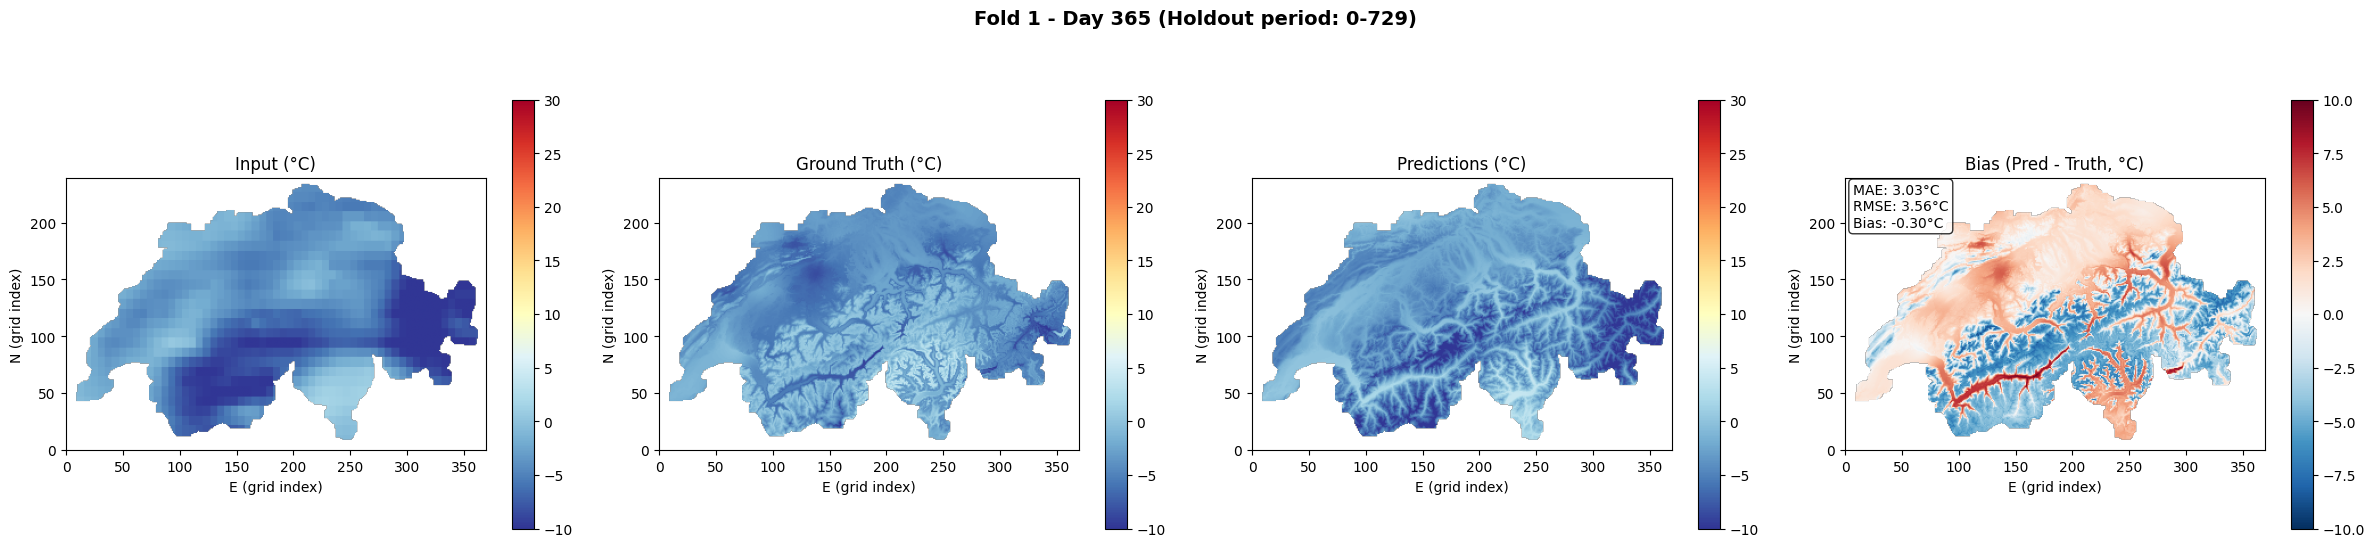

  Computing predictions for all 730 holdout days...
  Fold 1 done: accumulated 730 days

Fold 2/5
Built TmaxBiasConvCNPElev with 282,216 trainable parameters
  Loaded model from epoch 27
  Holdout period: days 730 to 1459 (730 days)
  Holdout date range: 2016-01-01T00:00:00.000000000 to 2017-12-30T00:00:00.000000000
  Selected day index for single-day plot: 1095
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_fold1_prediction.png


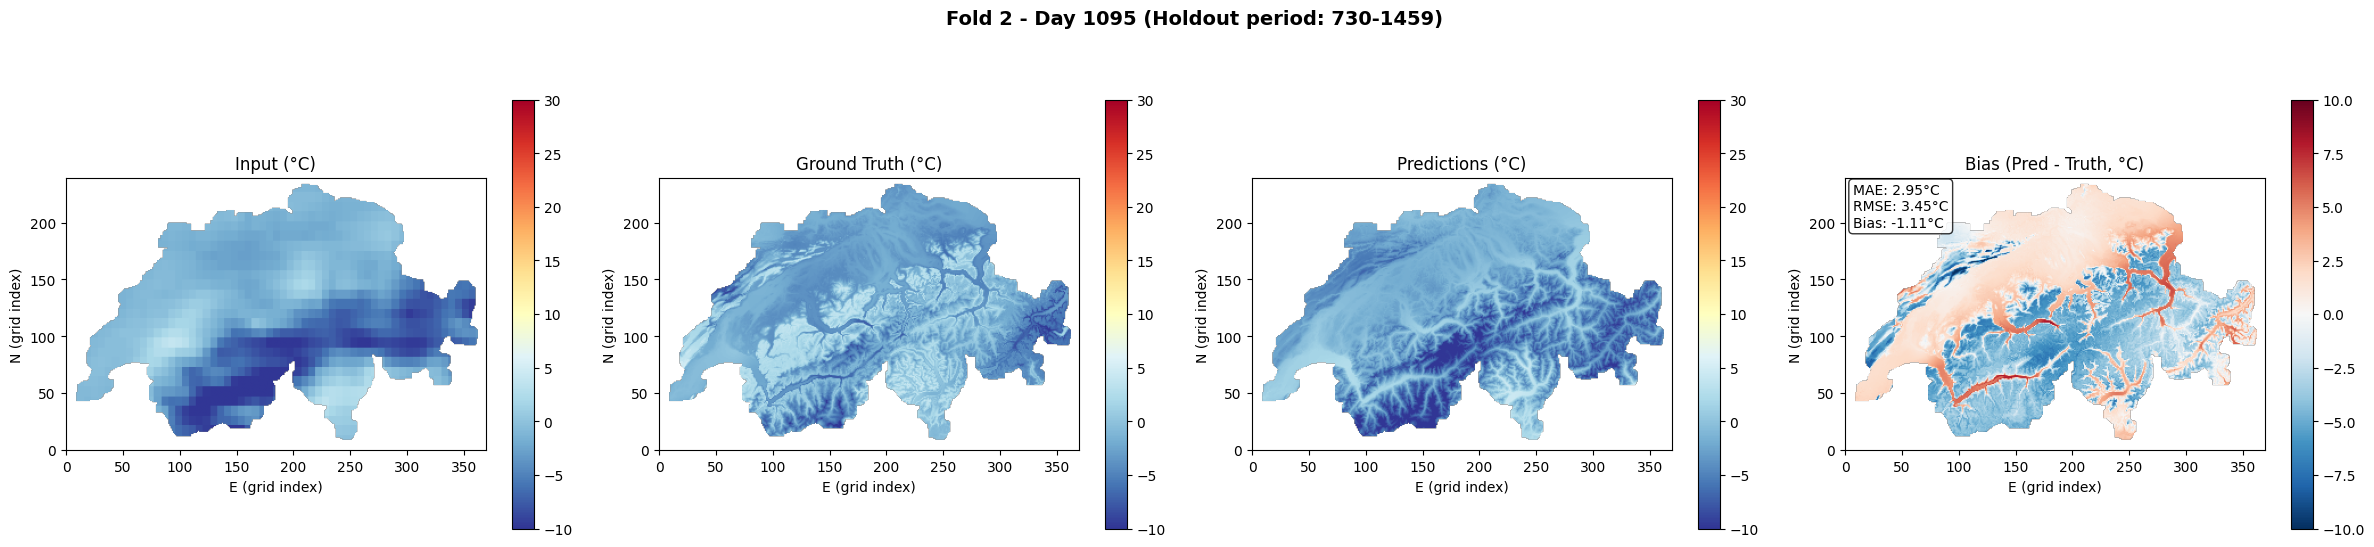

  Computing predictions for all 730 holdout days...
  Fold 2 done: accumulated 730 days

Fold 3/5
Built TmaxBiasConvCNPElev with 282,216 trainable parameters
  Loaded model from epoch 28
  Holdout period: days 1460 to 2189 (730 days)
  Holdout date range: 2017-12-31T00:00:00.000000000 to 2019-12-30T00:00:00.000000000
  Selected day index for single-day plot: 1825
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_fold2_prediction.png


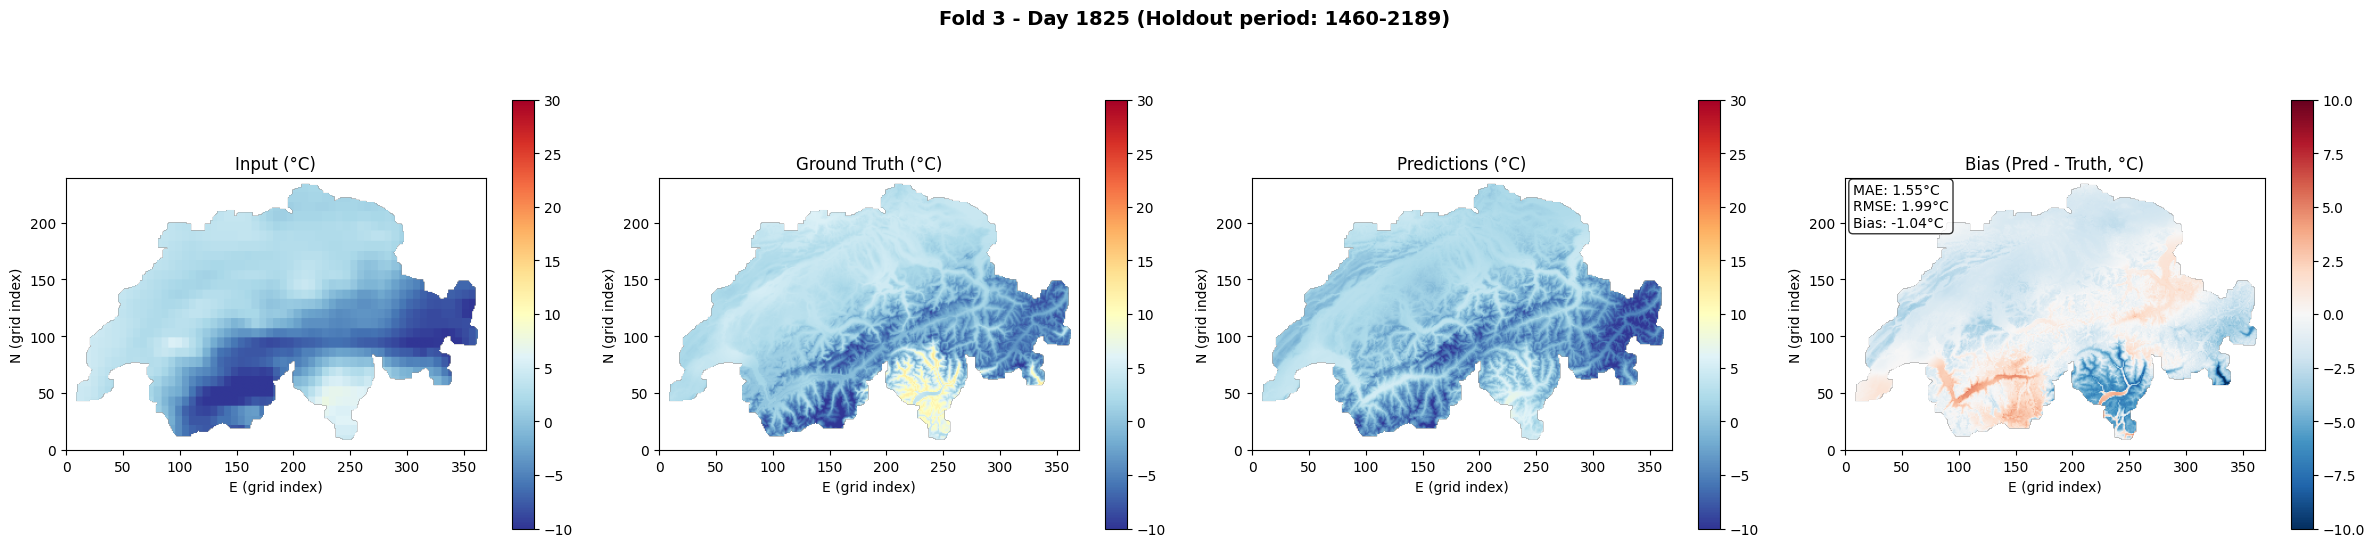

  Computing predictions for all 730 holdout days...
  Fold 3 done: accumulated 730 days

Fold 4/5
Built TmaxBiasConvCNPElev with 282,216 trainable parameters
  Loaded model from epoch 28
  Holdout period: days 2190 to 2919 (730 days)
  Holdout date range: 2019-12-31T00:00:00.000000000 to 2021-12-29T00:00:00.000000000
  Selected day index for single-day plot: 2555
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_fold3_prediction.png


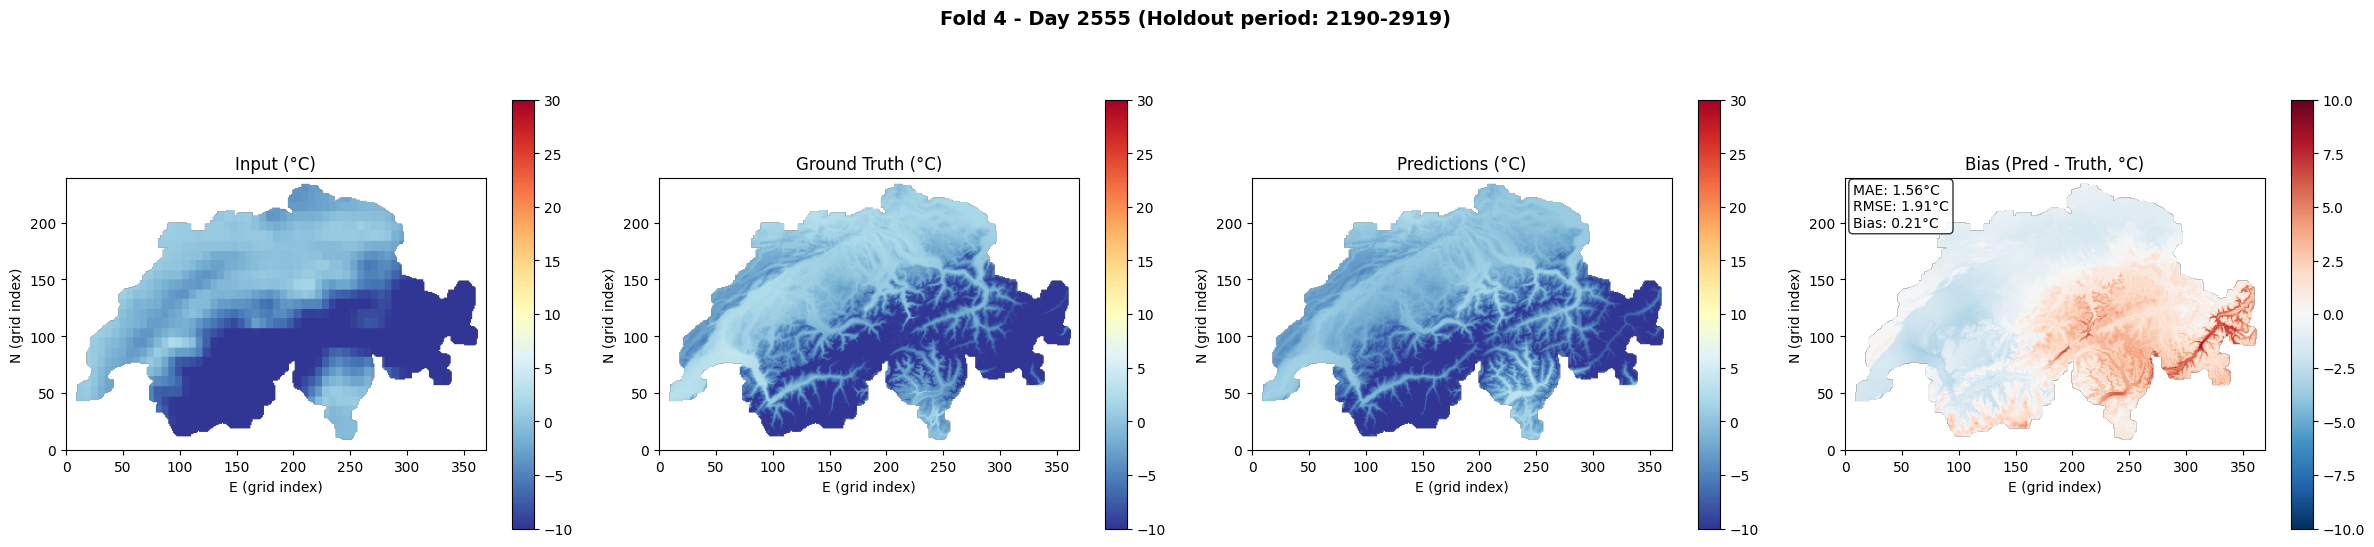

  Computing predictions for all 730 holdout days...
  Fold 4 done: accumulated 730 days

Fold 5/5
Built TmaxBiasConvCNPElev with 282,216 trainable parameters
  Loaded model from epoch 29
  Holdout period: days 2920 to 3651 (732 days)
  Holdout date range: 2021-12-30T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
  Selected day index for single-day plot: 3286
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_fold4_prediction.png


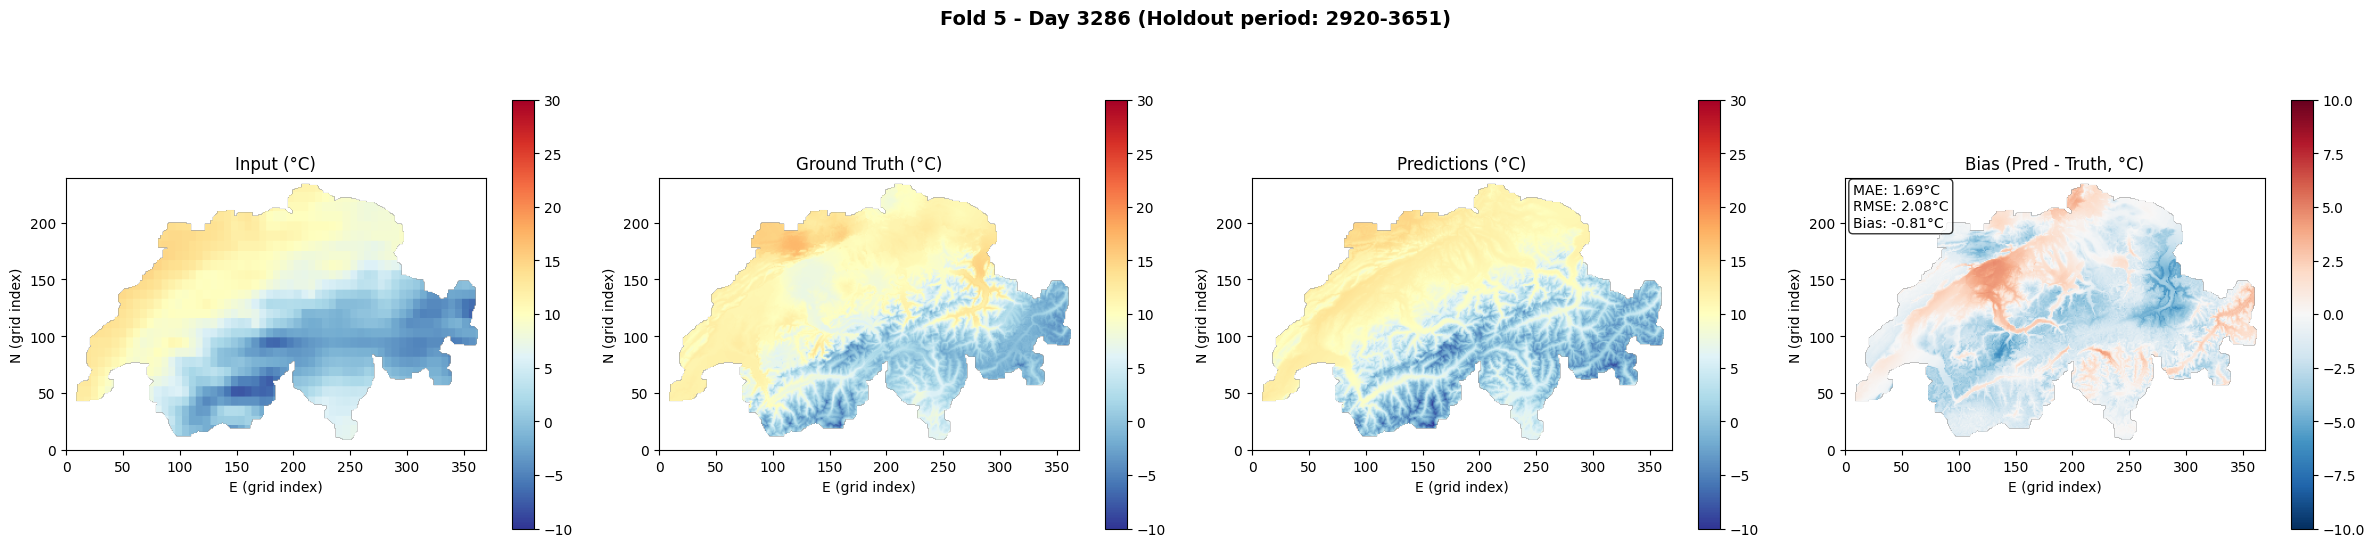

  Computing predictions for all 732 holdout days...
  Fold 5 done: accumulated 732 days

Combined holdout data: 3652 days x 88800 points


In [14]:
n_samples = era5_data.shape[0]
grid_shape = (grid_N, grid_E)
N, E = grid_shape

print(f"Total time samples: {n_samples}")
print(f"Number of folds: {params.N_FOLDS}")
print(f"ERA5 grid shape: {era5_shape}")
print(f"MeteoSwiss grid shape: {grid_shape}")
print(f"Input data: {INPUT_DATA}, sparsity: {SPARSITY_TYPE} = {SPARSITY_POINTS if is_sparse_points() else SPARSITY_PERCENT}")
print()

# Extract elevation and mTPI grids (these are static, same for all folds)
# elev tensor has shape (n_points, 3): [true_elev, elev_diff, mtpi]
elev_np = elev.cpu().numpy()
true_elev_grid = elev_np[:, 0].reshape(N, E)  # True elevation in meters
mtpi_grid = elev_np[:, 2].reshape(N, E)  # mTPI in meters

# Accumulators for combined holdout analysis
combined_errors = []       # List of (holdout_days_i, n_points) arrays
combined_preds = []        # Denormalized predictions (°C)
combined_sigmas = []       # Predicted sigma
combined_truths = []       # Denormalized ground truth (°C)
combined_dates = []        # Holdout dates for temporal analysis
combined_ref_preds = []    # ERA5 reference predictions for skill score

for fold in range(params.N_FOLDS):
    print(f"={'=' * 59}")
    print(f"Fold {fold + 1}/{params.N_FOLDS}")
    print(f"={'=' * 59}")
    
    # Load model checkpoint
    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue
    
    model, epoch = model_factory.load_model_checkpoint(checkpoint_path, params, device)
    print(f"  Loaded model from epoch {epoch}")
    
    # Get holdout period for this fold
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    holdout_days = holdout_end - holdout_start
    holdout_dates = era5_times[holdout_start:holdout_end]
    print(f"  Holdout period: days {holdout_start} to {holdout_end-1} ({holdout_days} days)")
    print(f"  Holdout date range: {holdout_dates[0]} to {holdout_dates[-1]}")
    
    # Select one day from holdout for the single-day visualization
    day_idx = select_holdout_day(fold, holdout_start, holdout_end, seed=params.SEED)
    print(f"  Selected day index for single-day plot: {day_idx}")
    
    # Generate predictions for single day visualization
    predictions, sigma = inf.predict_single_day(model, context_data, day_idx, dists, elev, seasonal_features, device)
    predictions_np = predictions.cpu().numpy()
    
    # Get ground truth and ERA5 input for single-day plot
    # Use context_data (not era5_data) so that sparse samples show only observed cells
    truth = target_y_tensor[day_idx].cpu().numpy()
    era5_temp = context_data[day_idx, 0].cpu().numpy()
    
    # Plot single-day comparison (kept per fold)
    title = f"Fold {fold + 1} - Day {day_idx} (Holdout period: {holdout_start}-{holdout_end-1})"
    fig = vis.plot_prediction_comparison(
        truth=truth,
        predictions=predictions_np,
        era5_input=era5_temp,
        grid_shape=grid_shape,
        era5_shape=era5_shape,
        metadata=metadata,
        title=title,
        denormalize=True,
        save_path=plot_path(f"fold{fold}_prediction"),
    )
    plt.show()
    
    # Compute predictions for all holdout days and accumulate
    print(f"  Computing predictions for all {holdout_days} holdout days...")
    
    fold_result = inf.predict_holdout_fold(
        model=model,
        context=context_data,
        holdout_start=holdout_start,
        holdout_end=holdout_end,
        dists=dists,
        elev=elev,
        seasonal=seasonal_features,
        target_y=target_y_tensor,
        metadata=metadata,
        device=device,
    )
    
    # Accumulate across folds
    combined_errors.append(fold_result.errors)
    combined_preds.append(fold_result.preds)
    combined_sigmas.append(fold_result.sigmas)
    combined_truths.append(fold_result.truths)
    combined_dates.append(holdout_dates)
    combined_ref_preds.append(era5_ref_denorm[holdout_start:holdout_end])
    
    print(f"  Fold {fold + 1} done: accumulated {fold_result.errors.shape[0]} days")
    print()

# Concatenate all folds along time axis
all_errors = np.concatenate(combined_errors, axis=0)
all_preds_denorm = np.concatenate(combined_preds, axis=0)
all_sigmas = np.concatenate(combined_sigmas, axis=0)
all_truths_denorm = np.concatenate(combined_truths, axis=0)
all_holdout_dates = np.concatenate(combined_dates, axis=0)
all_ref_preds = np.concatenate(combined_ref_preds, axis=0)

sigma_degC = all_sigmas * metadata.data_std

print(f"Combined holdout data: {all_errors.shape[0]} days x {all_errors.shape[1]} points")

## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Computing combined metrics over 3652 holdout days from 5 folds
Overall CRPS (°C): 0.772
Global skill score: 0.638
Overall MAE (°C): 1.067
Overall RMSE (°C): 1.434
Overall Bias (°C): -0.156
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_error_maps.png


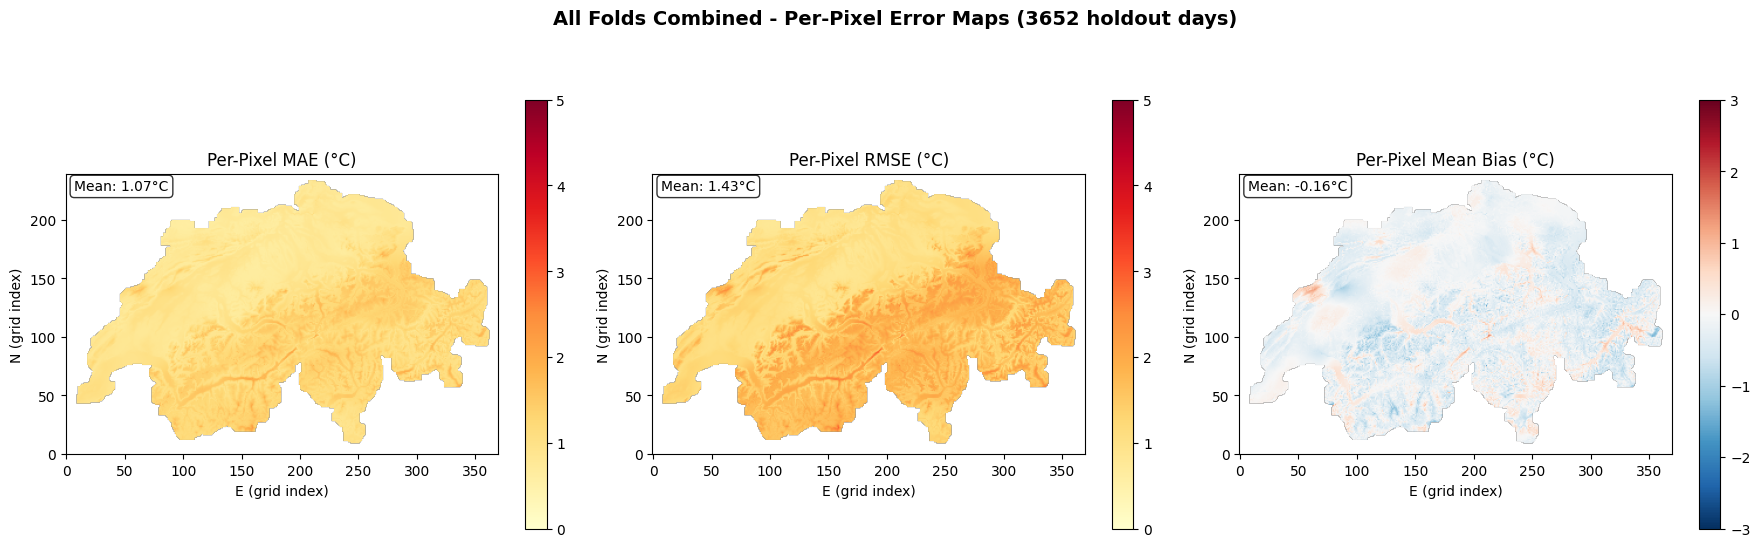

  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_uncertainty_vs_error.png


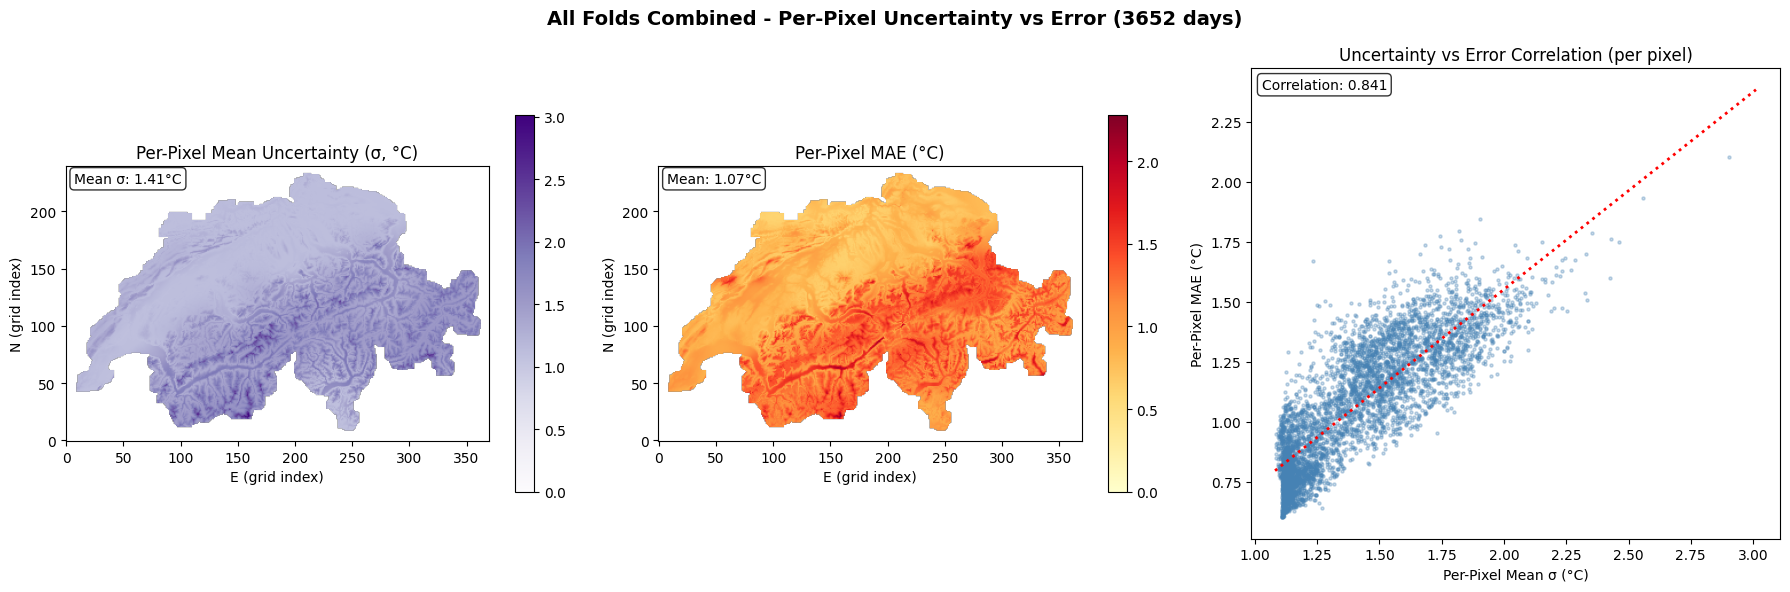

Per-pixel uncertainty-error correlation: 0.841
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_altitude_vs_error.png


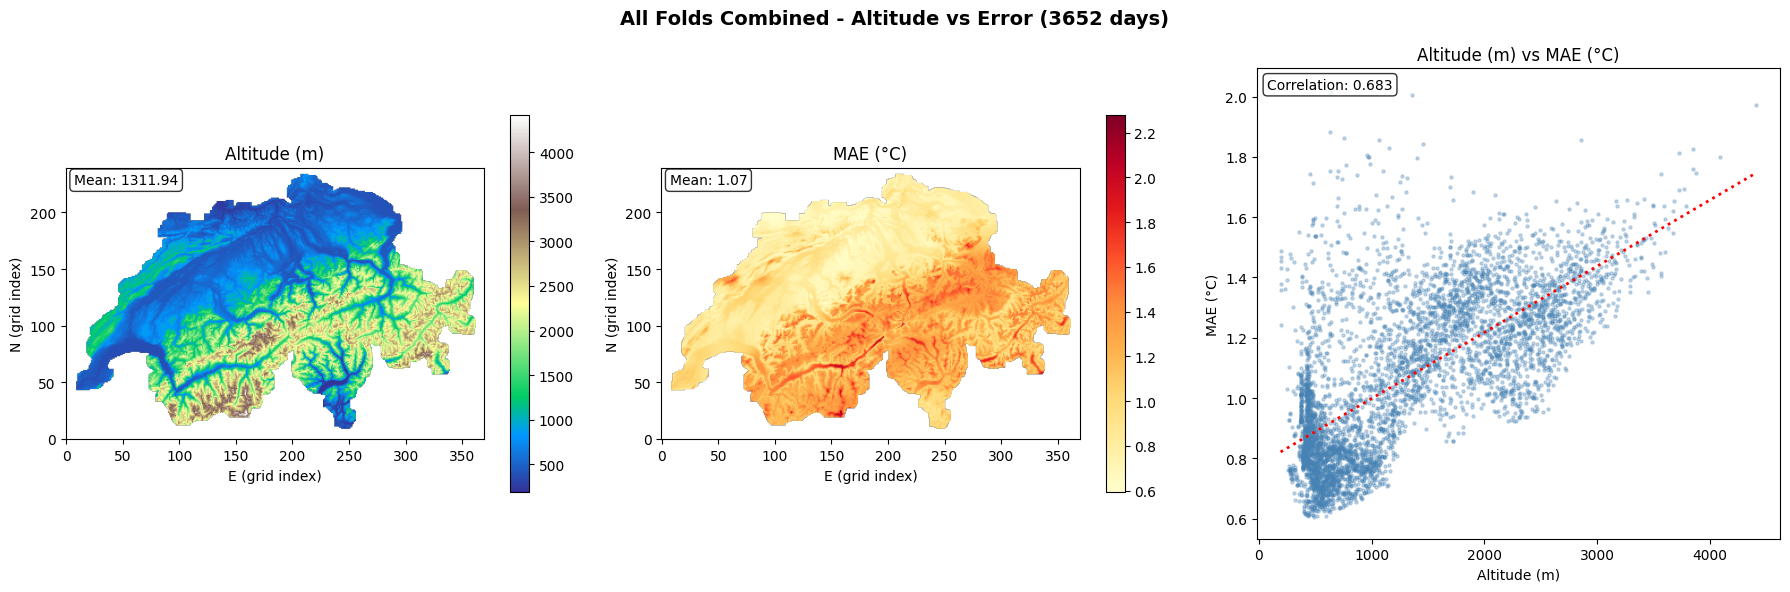

Altitude-error correlation: 0.683
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_mtpi_vs_error.png


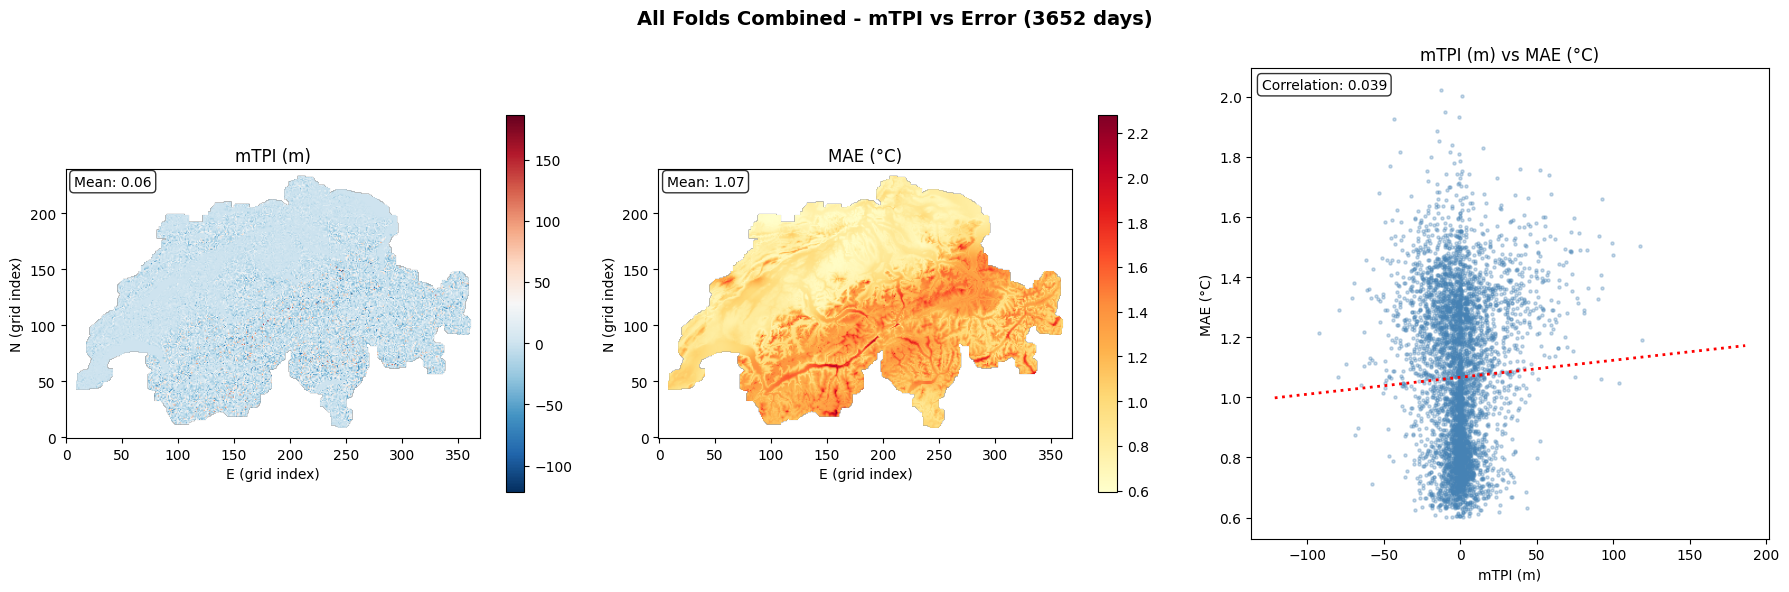

mTPI-error correlation: 0.039
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_doy_vs_error.png


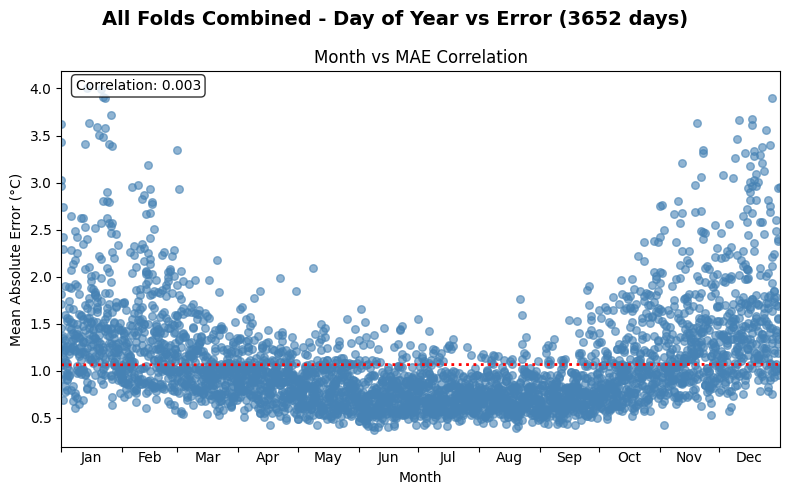

Day of year-error correlation: 0.003
  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_crps_map.png


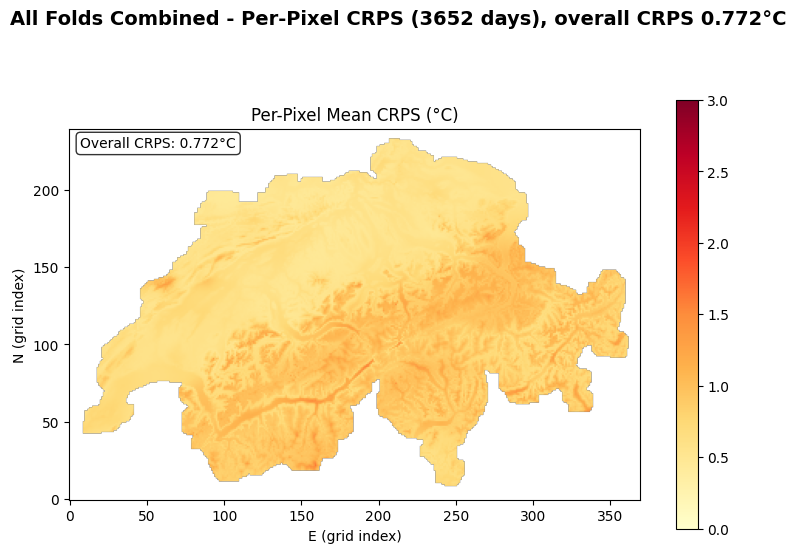

  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_skill_map.png


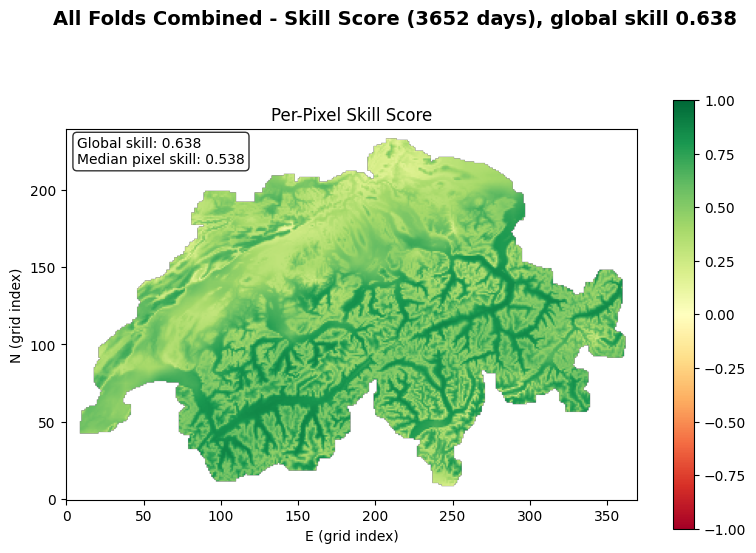

Saved grids to trained_models/final-2014-30e-5f-6in-mean/perpixel_grids.npz


In [15]:
# --- Per-pixel metrics across all folds ---
total_days = all_errors.shape[0]
print(f"Computing combined metrics over {total_days} holdout days from {params.N_FOLDS} folds")

# Compute valid mask from first time step
sample_truth = target_y_tensor[0].cpu().numpy().reshape(N, E)
valid_mask = ~np.isnan(sample_truth)

m = metrics.compute_perpixel_metrics(
    all_errors=all_errors,
    all_preds=all_preds_denorm,
    all_sigmas=sigma_degC,
    all_truths=all_truths_denorm,
    all_ref_preds=all_ref_preds,
    grid_shape=(N, E),
    valid_mask=valid_mask,
)

print(f"Overall CRPS (°C): {m.overall_crps:.3f}")
print(f"Global skill score: {m.global_skill:.3f}")
print(f"Overall MAE (°C): {np.nanmean(m.mae_grid):.3f}")
print(f"Overall RMSE (°C): {np.nanmean(m.rmse_grid):.3f}")
print(f"Overall Bias (°C): {np.nanmean(m.bias_grid):.3f}")

# Mask topography grids for correlation plots
true_elev_grid_masked = np.where(valid_mask, true_elev_grid, np.nan)
mtpi_grid_masked = np.where(valid_mask, mtpi_grid, np.nan)

# --- Plots ---

# 1. Error maps
fig_errors = vis.plot_error_maps(
    mae_grid=m.mae_grid, rmse_grid=m.rmse_grid, bias_grid=m.bias_grid,
    title=f"All Folds Combined - Per-Pixel Error Maps ({total_days} holdout days)",
    error_range=(0, 5), bias_range=(-3, 3),
    save_path=plot_path("error_maps"),
)
plt.show()

# 2. Per-pixel uncertainty vs error
fig_unc, perpixel_corr = vis.plot_perpixel_uncertainty_vs_error(
    mean_sigma_grid=m.mean_sigma_grid, mae_grid=m.mae_grid,
    title=f"All Folds Combined - Per-Pixel Uncertainty vs Error ({total_days} days)",
    sigma_range=(0, np.nanmax(m.mean_sigma_grid)),
    error_range=(0, np.nanmax(m.mae_grid)),
    save_path=plot_path("uncertainty_vs_error"),
)
plt.show()
print(f"Per-pixel uncertainty-error correlation: {perpixel_corr:.3f}")

# 3. Altitude vs error
fig_alt, alt_corr = vis.plot_perpixel_correlation(
    x_grid=true_elev_grid_masked, y_grid=m.mae_grid,
    x_label='Altitude (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - Altitude vs Error ({total_days} days)",
    x_cmap='terrain', y_cmap='YlOrRd',
    save_path=plot_path("altitude_vs_error"),
)
plt.show()
print(f"Altitude-error correlation: {alt_corr:.3f}")

# 4. mTPI vs error
fig_mtpi, mtpi_corr = vis.plot_perpixel_correlation(
    x_grid=mtpi_grid_masked, y_grid=m.mae_grid,
    x_label='mTPI (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - mTPI vs Error ({total_days} days)",
    x_cmap='RdBu_r', y_cmap='YlOrRd',
    save_path=plot_path("mtpi_vs_error"),
)
plt.show()
print(f"mTPI-error correlation: {mtpi_corr:.3f}")

# 5. Day of year vs error
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors, holdout_dates=all_holdout_dates,
    title=f"All Folds Combined - Day of Year vs Error ({total_days} days)",
    save_path=plot_path("doy_vs_error"),
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS map
fig_crps, _ = vis.plot_crps_map(
    crps_grid=m.crps_grid,
    title=f"All Folds Combined - Per-Pixel CRPS ({total_days} days), overall CRPS {m.overall_crps:.3f}°C",
    crps_range=(0, 3),
    save_path=plot_path("crps_map"),
)
plt.show()

# 7. Skill score map
fig_skill = vis.plot_skill_map(
    skill_grid=m.skill_grid, global_skill=m.global_skill,
    title=f"All Folds Combined - Skill Score ({total_days} days), global skill {m.global_skill:.3f}",
    save_path=plot_path("skill_map"),
)
plt.show()

np.savez(
    MODEL_DIR / 'perpixel_grids.npz',
    mae=m.mae_grid,
    rmse=m.rmse_grid,
    crps=m.crps_grid,
)
print(f"Saved grids to {MODEL_DIR / 'perpixel_grids.npz'}")

  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_qq_calibration.png


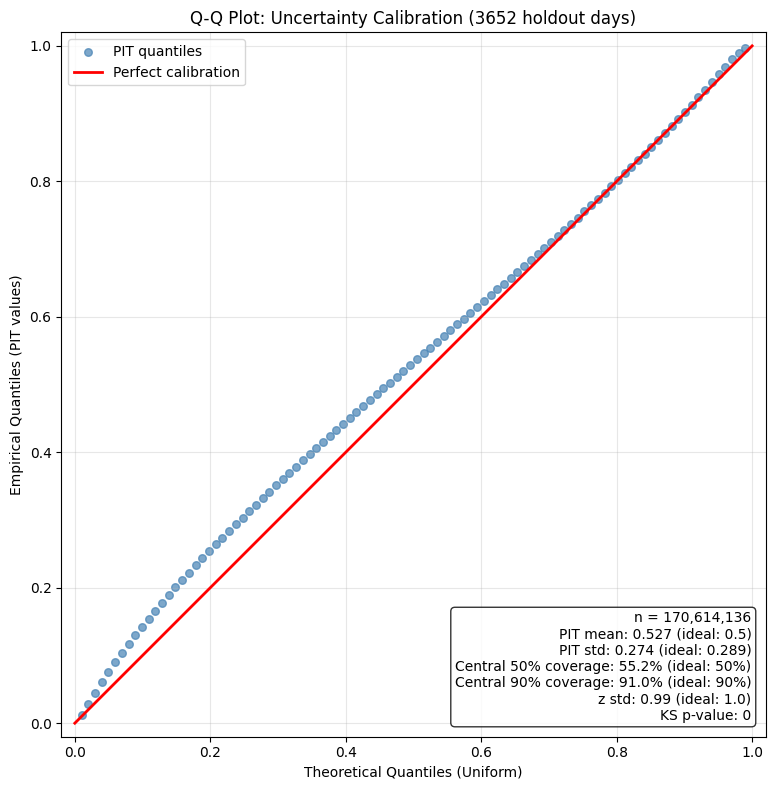


Calibration statistics:
  PIT mean: 0.527 (ideal: 0.5)
  PIT std:  0.274 (ideal: 0.289)
  z std:    0.99 (ideal: 1.0)
  50% coverage: 55.2% (ideal: 50%)
  90% coverage: 91.0% (ideal: 90%)
  KS test p-value: 0


In [16]:
from importlib import reload
vis = reload(vis)
# 8. Q-Q plot for uncertainty calibration
# Assesses whether the model's predicted uncertainty (sigma) is correctly calibrated.
# For a well-calibrated Gaussian model, PIT values (CDF of truth under predicted distribution)
# should follow Uniform(0, 1).
fig_qq, calibration_stats = vis.plot_qq_calibration(
    all_truths=all_truths_denorm,
    all_preds=all_preds_denorm,
    all_sigmas=sigma_degC,
    title=f"Q-Q Plot: Uncertainty Calibration ({total_days} holdout days)",
    save_path=plot_path("qq_calibration"),
)
plt.show()

print("\nCalibration statistics:")
print(f"  PIT mean: {calibration_stats['pit_mean']:.3f} (ideal: 0.5)")
print(f"  PIT std:  {calibration_stats['pit_std']:.3f} (ideal: 0.289)")
print(f"  z std:    {calibration_stats['z_std']:.2f} (ideal: 1.0)")
print(f"  50% coverage: {calibration_stats['coverage_50']:.1%} (ideal: 50%)")
print(f"  90% coverage: {calibration_stats['coverage_90']:.1%} (ideal: 90%)")
print(f"  KS test p-value: {calibration_stats['ks_p']:.3g}")

  Saved plot: trained_models/final-2014-30e-5f-6in-mean/plots/ERA5_GRID_PERCENT_1.0_reliability_diagram.png


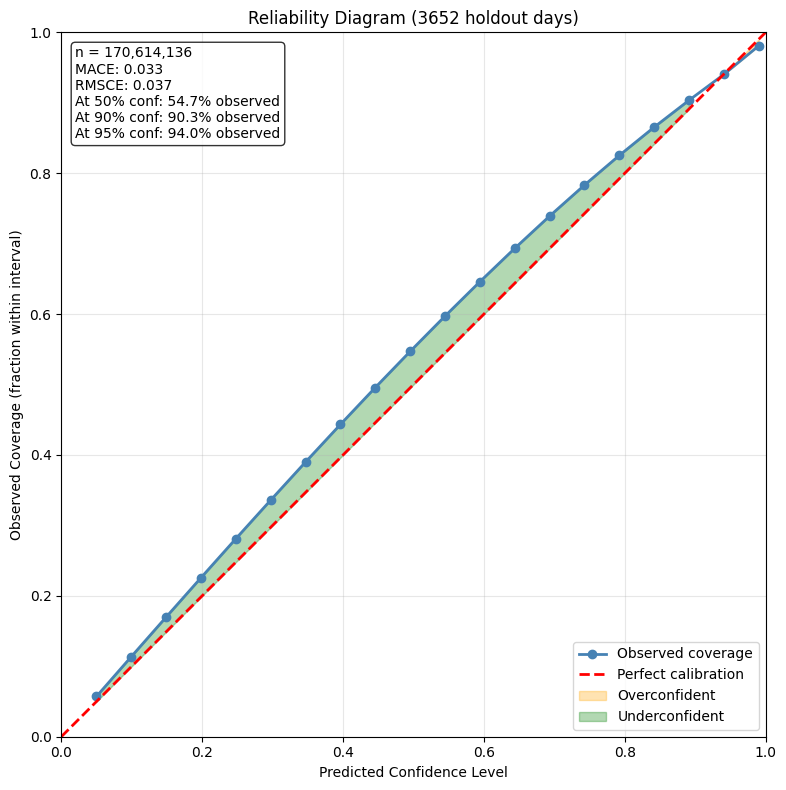


Reliability statistics:
  Mean Absolute Calibration Error (MACE): 0.033
  At 50% confidence: 54.7% observed (ideal: 50%)
  At 90% confidence: 90.3% observed (ideal: 90%)
  At 95% confidence: 94.0% observed (ideal: 95%)


In [17]:
# 9. Reliability diagram for uncertainty calibration
# Shows predicted confidence level vs observed coverage.
# If well-calibrated, the curve should follow the diagonal.
fig_reliability, reliability_stats = vis.plot_reliability_diagram(
    all_truths=all_truths_denorm,
    all_preds=all_preds_denorm,
    all_sigmas=sigma_degC,
    title=f"Reliability Diagram ({total_days} holdout days)",
    save_path=plot_path("reliability_diagram"),
)
plt.show()

print("\nReliability statistics:")
print(f"  Mean Absolute Calibration Error (MACE): {reliability_stats['mace']:.3f}")
print(f"  At 50% confidence: {reliability_stats['coverage_at_50']:.1%} observed (ideal: 50%)")
print(f"  At 90% confidence: {reliability_stats['coverage_at_90']:.1%} observed (ideal: 90%)")
print(f"  At 95% confidence: {reliability_stats['coverage_at_95']:.1%} observed (ideal: 95%)")

In [18]:
import json

sparsity_value = SPARSITY_PERCENT if is_sparse_percent() else SPARSITY_POINTS
metrics_filename = f"metrics-{INPUT_DATA}-{SPARSITY_TYPE}-{sparsity_value}.json"
metrics_path = MODEL_DIR / metrics_filename

metrics_dict = {
    "config": {
        "model_name": MODEL_NAME,
        "input_data": INPUT_DATA,
        "sparsity_type": SPARSITY_TYPE,
        "sparsity_value": sparsity_value,
        "n_folds": params.N_FOLDS,
        "holdout_days": int(total_days),
    },
    "overall": {
        "mae": float(np.nanmean(m.mae_grid)),
        "rmse": float(np.nanmean(m.rmse_grid)),
        "bias": float(np.nanmean(m.bias_grid)),
        "crps": float(m.overall_crps),
        "skill_score": float(m.global_skill),
    },
    "correlations": {
        "uncertainty_error": float(perpixel_corr),
        "altitude_error": float(alt_corr),
        "mtpi_error": float(mtpi_corr),
        "doy_error": float(doy_corr),
    },
    "calibration": {
        "pit_mean": float(calibration_stats["pit_mean"]),
        "pit_std": float(calibration_stats["pit_std"]),
        "z_std": float(calibration_stats["z_std"]),
        "coverage_50": float(calibration_stats["coverage_50"]),
        "coverage_90": float(calibration_stats["coverage_90"]),
        "ks_p_value": float(calibration_stats["ks_p"]),
    },
    "reliability": {
        "mace": float(reliability_stats["mace"]),
        "coverage_at_50": float(reliability_stats["coverage_at_50"]),
        "coverage_at_90": float(reliability_stats["coverage_at_90"]),
        "coverage_at_95": float(reliability_stats["coverage_at_95"]),
    },
}

metrics_path.write_text(json.dumps(metrics_dict, indent=2))
print(f"Metrics saved to {metrics_path}")

Metrics saved to trained_models/final-2014-30e-5f-6in-mean/metrics-ERA5_GRID-PERCENT-1.0.json


## Summary

This notebook demonstrates how to:
1. Load trained convCNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Generate spatial predictions for the entire MeteoSwiss grid
4. **Per-fold:** Visualize a single representative day showing ERA5 input, ground truth, predictions, and bias
   The residual maps show where the model performs well (white) and where it struggles (blue=lower predictions, red=higher predictions).
5. **Combined across all folds:** Since holdout periods are non-overlapping, predictions from all folds are concatenated to produce a unified evaluation covering the entire year:
   - Per-pixel error maps (MAE, RMSE, bias)
   - Uncertainty calibration (predicted σ vs actual MAE)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to ERA5 bilinear interpolation baseline
   - Q-Q plot using Probability Integral Transform (PIT)
   - Reliability diagram for confidence calibration

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration - the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period

### Interpretation of calibration plots:

**Q-Q Plot (PIT-based):**
- Computes PIT = CDF(truth | μ, σ) for each prediction
- If well-calibrated, PIT values should be Uniform(0,1)
- Points on diagonal = well-calibrated
- S-curve below diagonal = overconfident (intervals too narrow)
- S-curve above diagonal = underconfident (intervals too wide)

**Reliability Diagram:**
- X-axis: Predicted confidence level (e.g., 50%, 90%, 95%)
- Y-axis: Observed frequency (fraction of truths actually in that interval)
- Diagonal = perfect calibration
- Curve below diagonal (orange region) = overconfident
- Curve above diagonal (green region) = underconfident
- MACE (Mean Absolute Calibration Error) summarizes miscalibration